Cargando imágenes...


Cargando cardboard:   0%|          | 0/403 [00:00<?, ?img/s]

Cargando glass:   0%|          | 0/501 [00:00<?, ?img/s]

Cargando metal:   0%|          | 0/410 [00:00<?, ?img/s]

Cargando paper:   0%|          | 0/594 [00:00<?, ?img/s]

...


🚀 Entrenando CNN Avanzada SIN Data Augmentation y SIN Early Stopping...


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


 RESULTADOS PARA EL README 
Modelo: CNN (Sin Augmentation, Sin EarlyStopping)
Accuracy Train: 0.9578
Accuracy Val:   0.7589
Accuracy Test:  0.7628


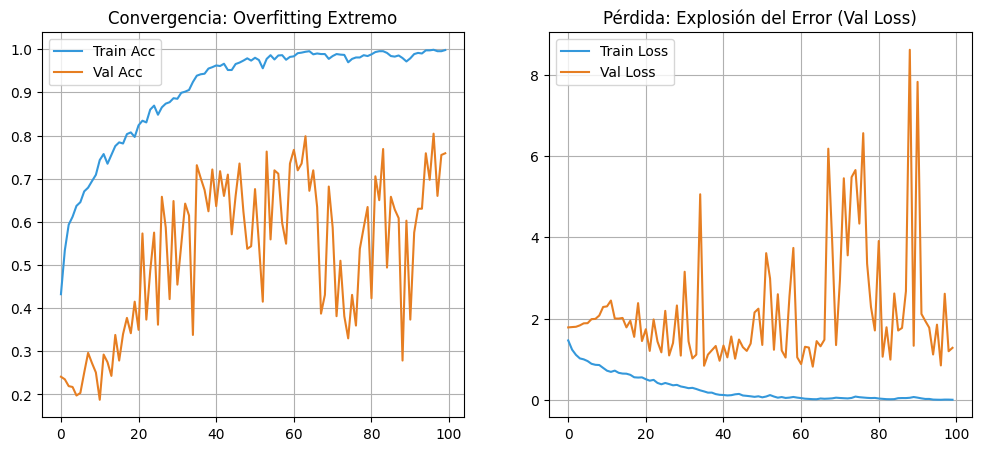

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.keras import TqdmCallback
import glob
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

# 1. IMPORTAR EL MODELO SIN AUGMENTATION
sys.path.append(os.path.abspath('.'))
from modelos.modelo_cnn_1 import obtener_modelo_cnn_1 

# =========================================================
# 2. CARGAR Y PREPARAR LOS DATOS (Asumiendo que ya están cargados,
# pero lo dejamos por si acaso reiniciaste el kernel)
# =========================================================
PATH_DATOS = 'data/' 
IMG_SIZE = (64, 64) 

def cargar_datos(path):
    X_list, y_list = [], []
    if not os.path.exists(path):
        print(f"❌ ERROR CRÍTICO: La carpeta '{path}' no existe.")
        return np.array([]), np.array([]), []
        
    categorias = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    
    if len(categorias) == 0:
        return np.array([]), np.array([]), []

    for idx, cat in enumerate(categorias):
        files = glob.glob(os.path.join(path, cat, '*'))
        for f in tqdm(files, desc=f"Cargando {cat}", unit="img"):
            try:
                img = Image.open(f).convert('RGB').resize(IMG_SIZE)
                X_list.append(np.array(img))
                y_list.append(idx)
            except Exception:
                continue
                
    return np.array(X_list), np.array(y_list), categorias

# Solo cargamos si no existen en memoria para ahorrar tiempo
if 'X_img' not in locals():
    print("Cargando imágenes...")
    X_img, y, nombres_clases = cargar_datos(PATH_DATOS)

# Normalizamos y dividimos
X_norm = X_img / 255.0
X_train_val, X_test, y_train_val, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

# 2. INICIALIZAR EL MODELO
input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))
model = obtener_modelo_cnn_1(input_shape, num_classes) 

# 3. ENTRENAMIENTO KAMIKAZE (Sin Early Stopping)
print("\n🚀 Entrenando CNN Avanzada SIN Data Augmentation y SIN Early Stopping...")
history = model.fit(X_train, y_train, 
                    epochs=100, # Le dejamos las 100 épocas enteras
                    batch_size=64, 
                    validation_data=(X_val, y_val),
                    callbacks=[TqdmCallback(verbose=1)], # Adiós al callback de convergencia
                    verbose=0)

# 4. EVALUACIÓN Y RESULTADOS FINALES
acc_train = model.evaluate(X_train, y_train, verbose=0)[1]
acc_val = model.evaluate(X_val, y_val, verbose=0)[1]
acc_test = model.evaluate(X_test, y_test, verbose=0)[1]

print(f"\n{'='*40}")
print(f" RESULTADOS PARA EL README ")
print(f"{'='*40}")
print(f"Modelo: CNN (Sin Augmentation, Sin EarlyStopping)")
print(f"Accuracy Train: {acc_train:.4f}")
print(f"Accuracy Val:   {acc_val:.4f}")
print(f"Accuracy Test:  {acc_test:.4f}")

# 5. CURVAS DE CONVERGENCIA
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', color='#3498db')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='#e67e22')
plt.title('Convergencia: Overfitting Extremo')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#3498db')
plt.plot(history.history['val_loss'], label='Val Loss', color='#e67e22')
plt.title('Pérdida: Explosión del Error (Val Loss)')
plt.legend(); plt.grid(True)
plt.show()